In [28]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_solver
from lib_fitting import Lagrange, lagrange_int


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:

# plt.rcParams.update({
#     "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
#     "font.family": "serif",        # Usa un font Serif per il testo normale
#     "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
#     "axes.labelsize": 16,          # Dimensione font etichette assi
#     "font.size": 14,                # Dimensione font generale
#     "legend.fontsize": 14,         # Dimensione font legenda
#     "xtick.labelsize": 13,         # Dimensione numeri asse x
#     "ytick.labelsize": 13,         # Dimensione numeri asse y
#     "figure.figsize": (8, 6),      # Dimensione predefinita della figura
#     "figure.dpi": 100,             # Risoluzione
    
#     "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
# })

Take Runge’s function$$\frac{1}{1 + 25x^2}$$in the interval $[-1, 1]$. Calculate the interpolating function using $N = 10, 20, 30, 40, 50$ nodes defined both as equidistant nodes and Chebyshev ones. Use the interpolator based on Lagrange polynomials and the monomial basis (direct method with Vandermonde matrix) constructed in the previous Module.

## **Uniform Nodes**

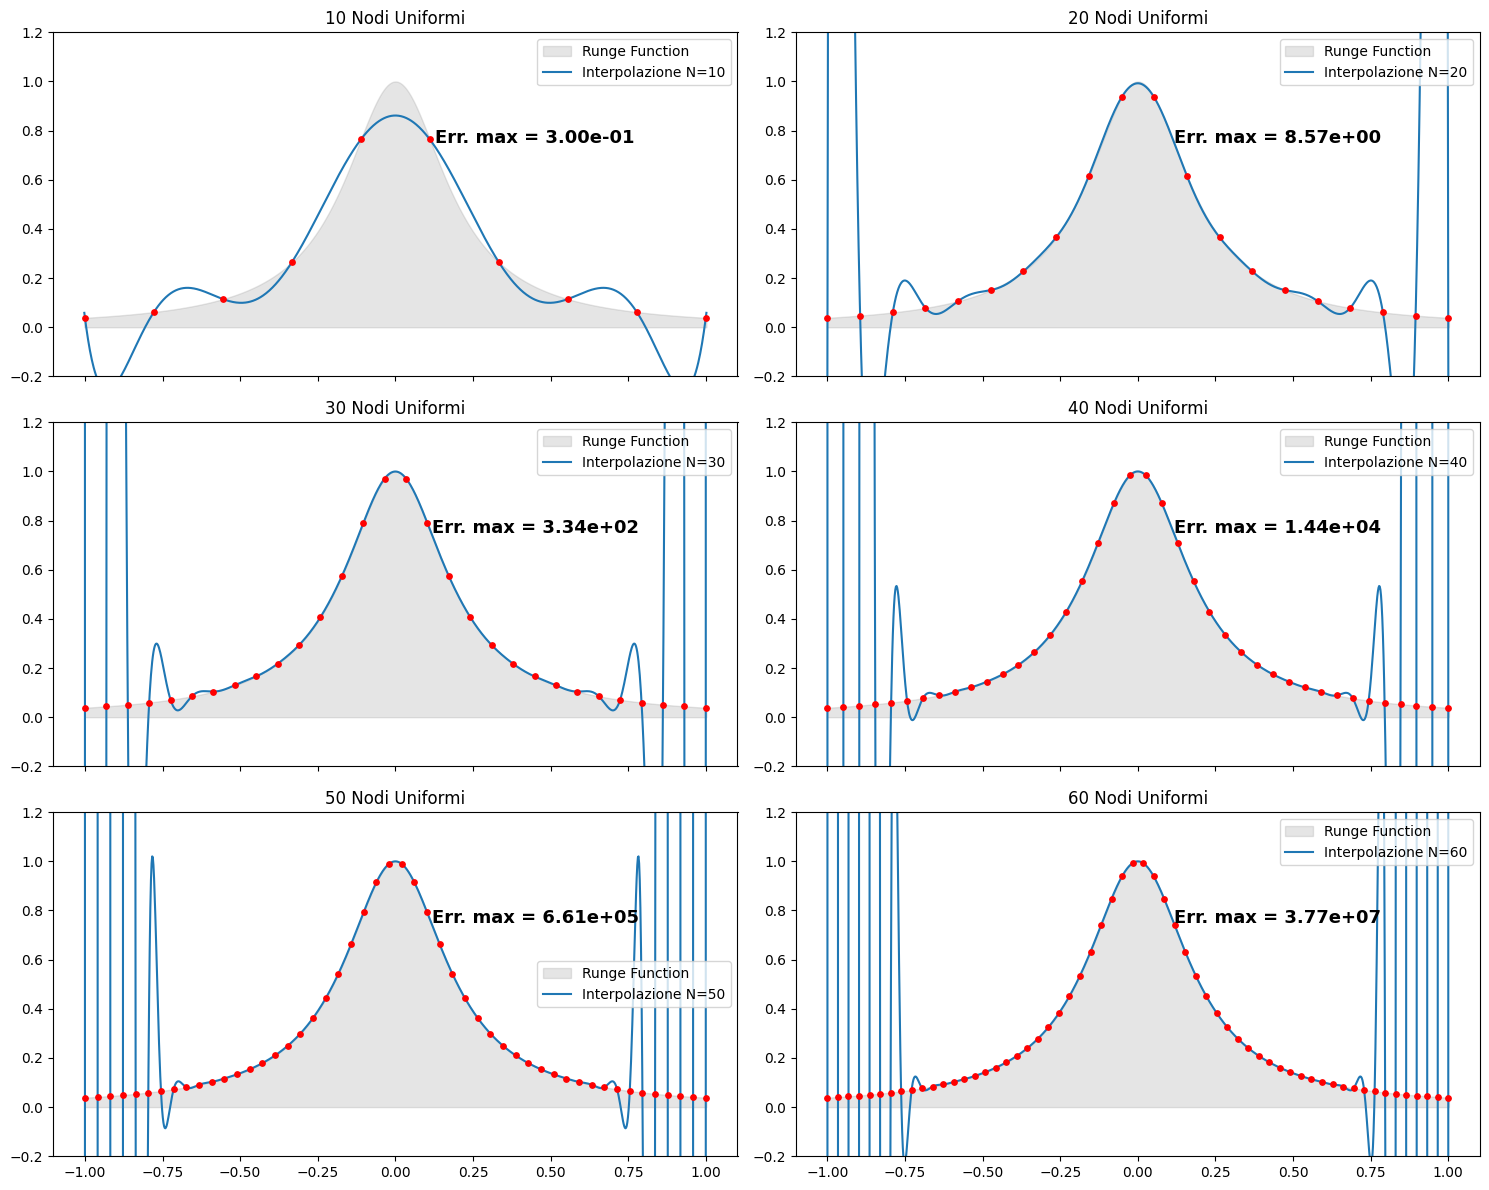

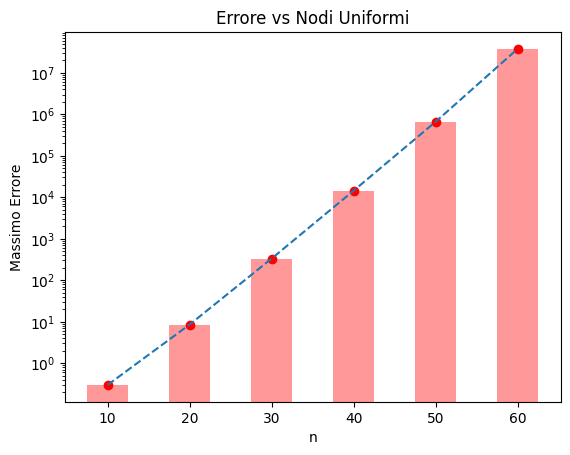

In [30]:
def Runge_fun(x):
    return 1 / (1 + 25*x**2)

x_ls = []
errs = []
for i in np.linspace(10, 60, 6, dtype=int):
    x_ls.append(np.linspace(-1, 1, i))

fig, ax = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
ax = ax.flatten() 

for n, ele in enumerate(x_ls):
    f = Runge_fun(ele)
    x_int, y_int = lagrange_int(ele, f)
    y_fine = Runge_fun(x_int)
    err_max = np.max(np.abs(y_int - y_fine))
    errs.append(err_max)
    
    ax[n].fill_between(x_int, y_fine, color='gray', alpha=0.2, label=r'Runge Function')
    ax[n].plot(x_int, y_int, label=f'Interpolazione N={len(ele)}')
    ax[n].scatter(ele, f, s=15, color='red', zorder=3)
    
    ax[n].set_ylim(-0.2, 1.2)
    ax[n].set_title(rf"{len(ele)} Nodi Uniformi")
    ax[n].text(0.45, 0.75, rf"Err. max = {err_max:.2e}", fontsize=13, color='black', fontweight='bold', ha='center')
    ax[n].legend()

plt.tight_layout()
# plt.savefig('plots/unif_lagrange.png', dpi=300)
plt.show()


plt.plot(np.arange(10, 70, step=10), errs, ls='--')
plt.bar(np.arange(10, 70, step=10), errs, width=5, color='red', alpha=0.4)
plt.scatter(np.arange(10, 70, step=10), errs, color='red')
plt.yscale('log')
plt.xlabel(r'n')
plt.ylabel('Massimo Errore')
plt.title('Errore vs Nodi Uniformi')
plt.show()

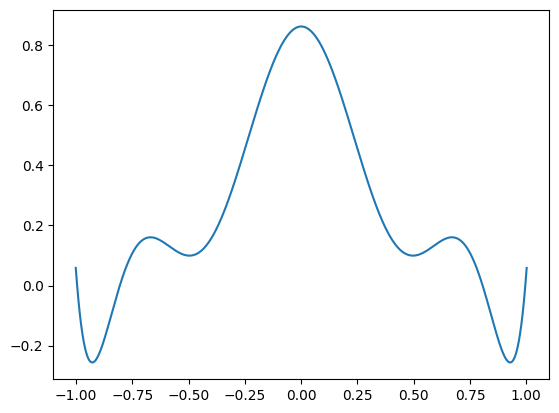

In [31]:
def Direct_mth(xarr, yarr, N_points=1000):
    ls = []
    for i in range(len(xarr)):
        ls.append(xarr**i)
    vanderm =  np.array(ls).T
    a_arr = np.flip(QR_solver(vanderm, yarr))

    xoff = 0.001*(max(xarr) - min(xarr))
    x_in = np.linspace(xarr[0]-xoff, xarr[-1]+xoff, N_points)
    y_in = np.polyval(a_arr, x_in)
    return x_in, y_in

x = np.linspace(-1, 1, 10)
y = Runge_fun(x)

xout, yout = Direct_mth(x, y)

plt.plot(xout, yout)
plt.show()


Error in QR decomposition! Vandermond Matrix is ill-conditioned for n = 40
Error in QR decomposition! Vandermond Matrix is ill-conditioned for n = 50
Error in QR decomposition! Vandermond Matrix is ill-conditioned for n = 60


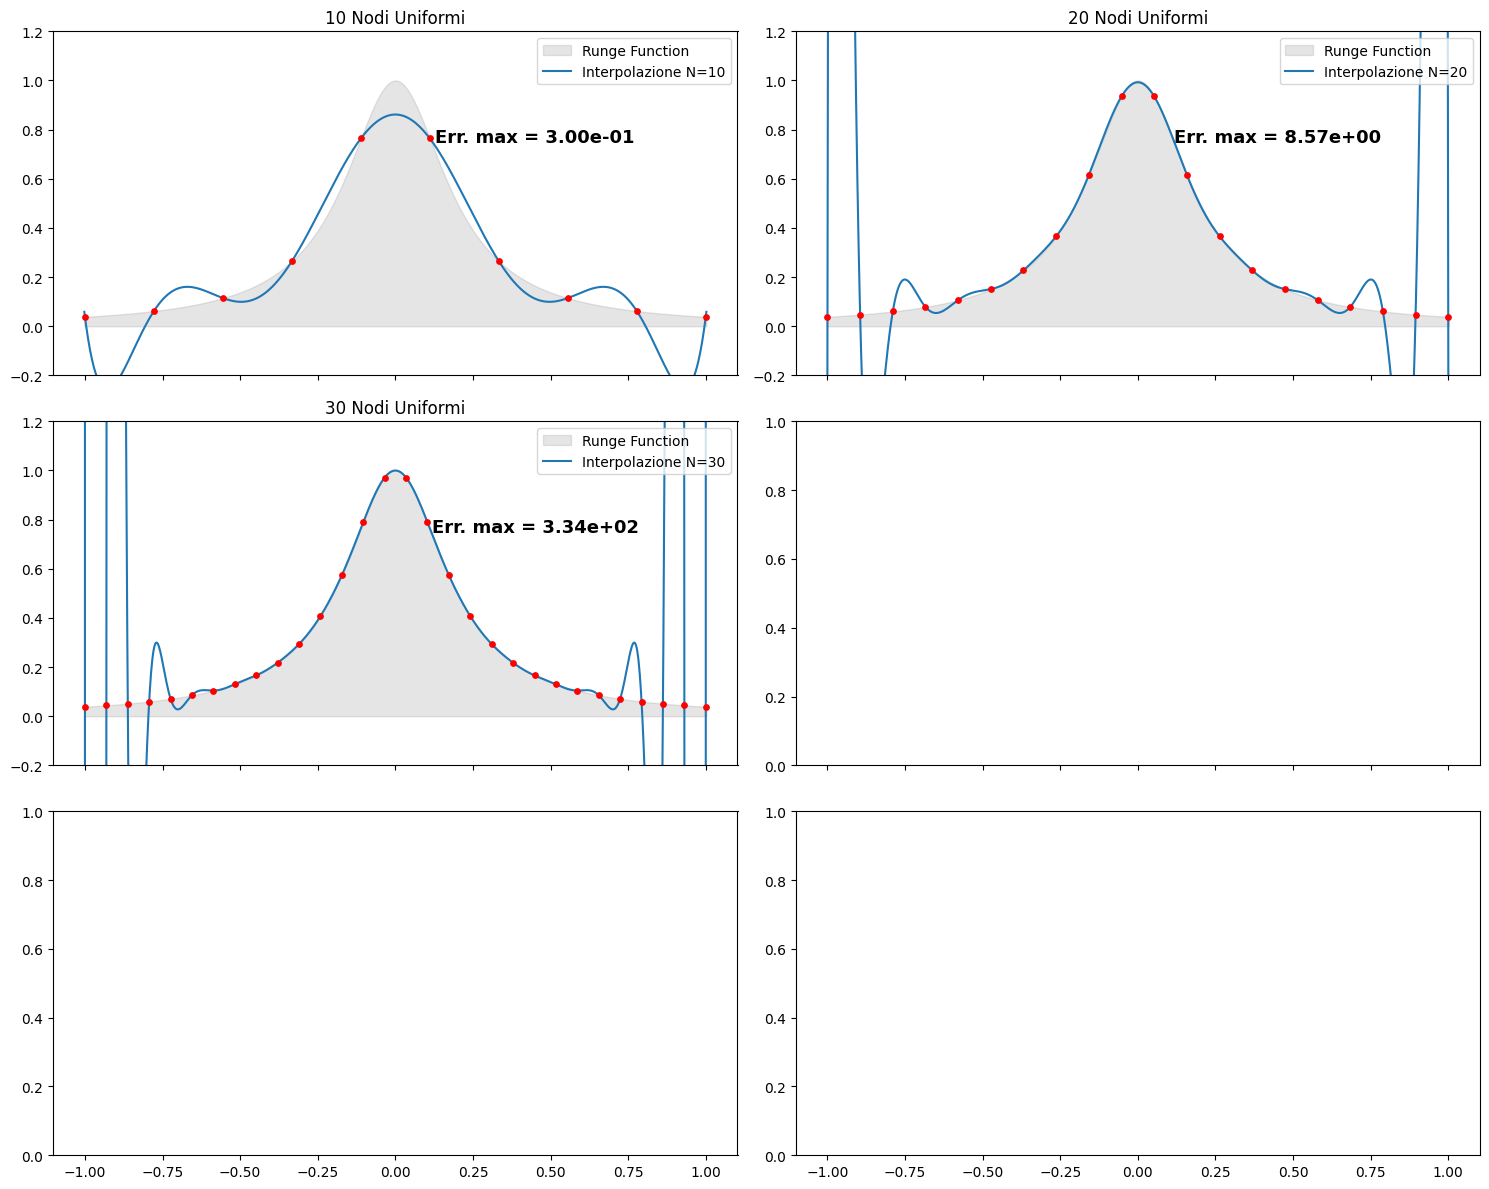

ValueError: x and y must have same first dimension, but have shapes (6,) and (3,)

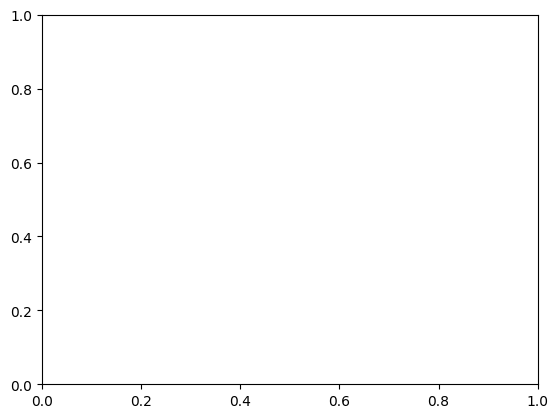

In [32]:



x_ls = []
errs = []
for i in np.linspace(10, 60, 6, dtype=int):
    x_ls.append(np.linspace(-1, 1, i))

fig, ax = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
ax = ax.flatten() 
for n, ele in enumerate(x_ls):
    f = Runge_fun(ele)
    try:    
        x_int, y_int = Direct_mth(ele, f)
        y_fine = Runge_fun(x_int)
        err_max = np.max(np.abs(y_int - y_fine))
        errs.append(err_max)
        
        ax[n].fill_between(x_int, y_fine, color='gray', alpha=0.2, label=r'Runge Function')
        ax[n].plot(x_int, y_int, label=f'Interpolazione N={len(ele)}')
        ax[n].scatter(ele, f, s=15, color='red', zorder=3)
        
        ax[n].set_ylim(-0.2, 1.2)
        ax[n].set_title(rf"{len(ele)} Nodi Uniformi")
        ax[n].text(0.45, 0.75, rf"Err. max = {err_max:.2e}", fontsize=13, color='black', fontweight='bold', ha='center')
        ax[n].legend()
    except Exception as e:
        print(f'Error in QR decomposition! Vandermond Matrix is ill-conditioned for n = {len(ele)}')
        
plt.tight_layout()
# plt.savefig('plots/unif_lagrange.png', dpi=300)
plt.show()


plt.plot(np.arange(10, 70, step=10), errs, ls='--')
plt.bar(np.arange(10, 70, step=10), errs, width=5, color='red', alpha=0.4)
plt.scatter(np.arange(10, 70, step=10), errs, color='red')
plt.yscale('log')
plt.xlabel(r'n')
plt.ylabel('Massimo Errore')
plt.title('Errore vs Nodi Uniformi')
plt.show()


## **Chebyschev Nodes**

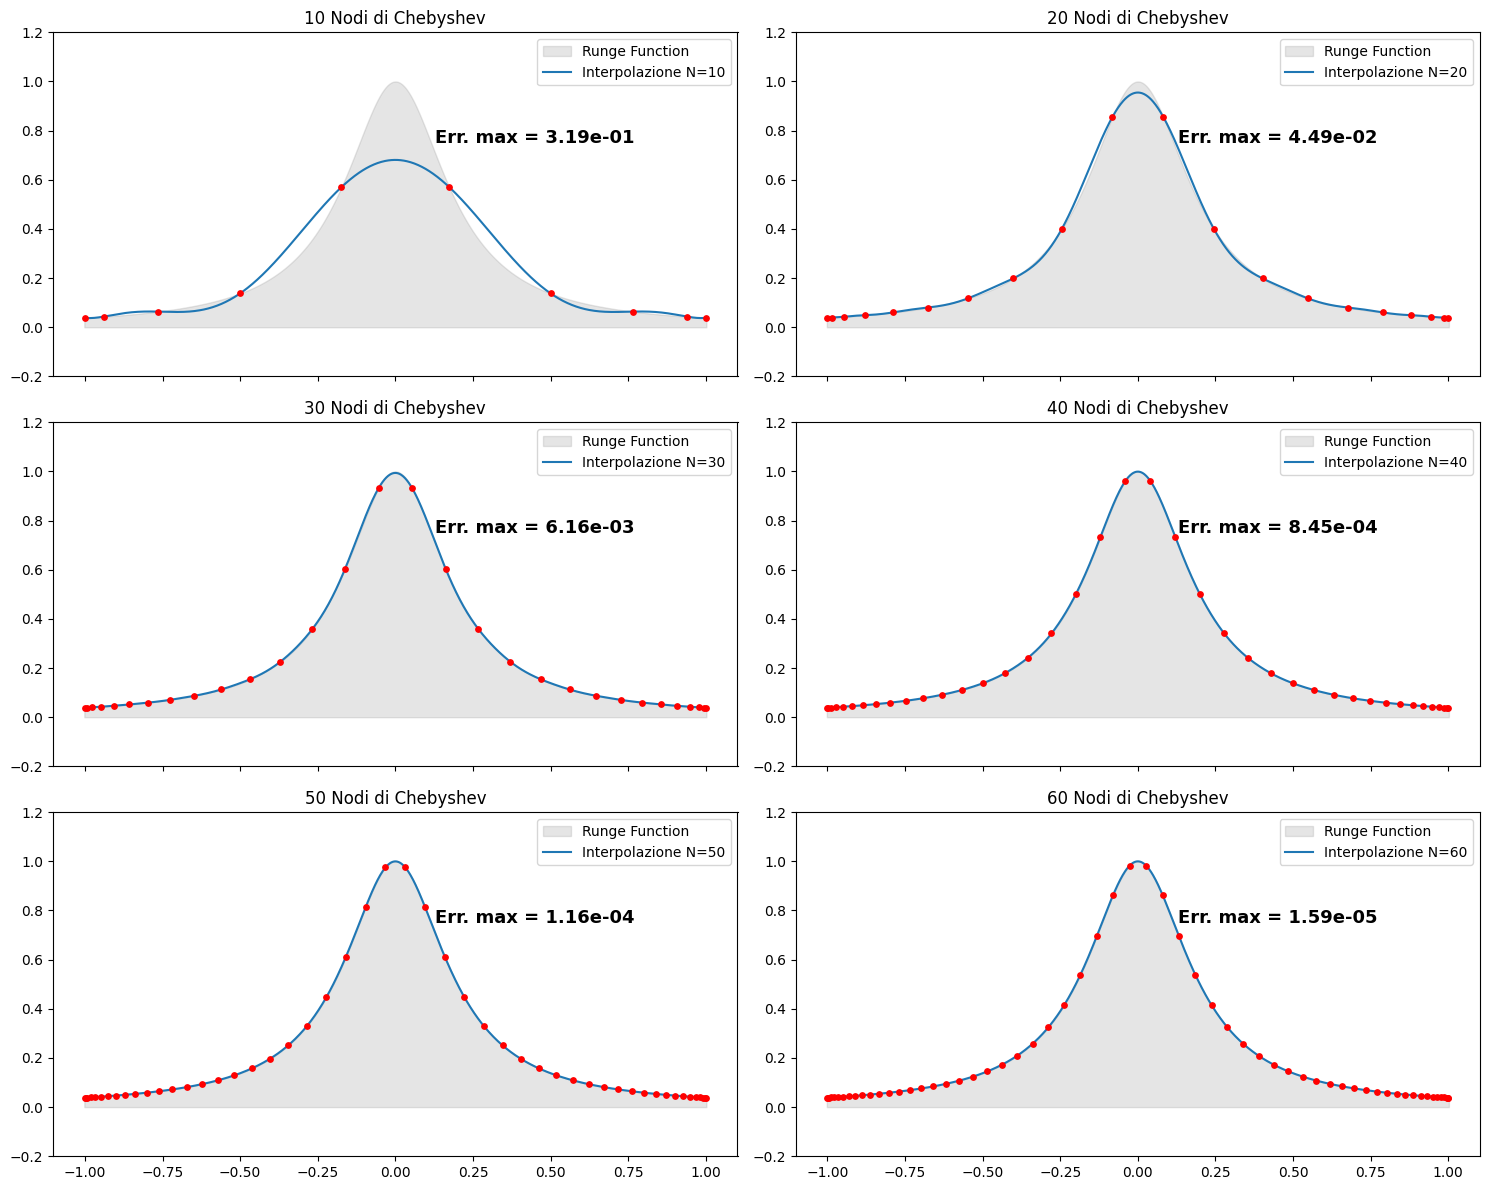

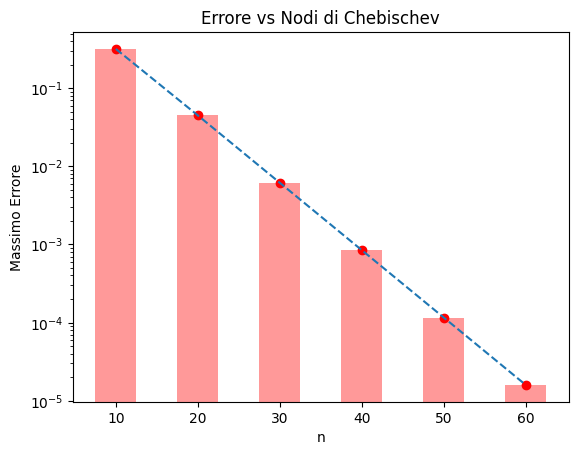

In [ ]:
def Cheby_nodes(dim):
    j = np.arange(dim)
    return -np.cos(j*np.pi / (dim-1))

errs = []
fig, ax = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
ax = ax.flatten() 

for n, N_val in enumerate([10, 20, 30, 40, 50, 60]):
    # Generazione nodi di Chebyshev
    ele = Cheby_nodes(N_val)
    
    # Calcolo funzione e interpolazione
    f = Runge_fun(ele)
    x_int, y_int = lagrange_int(ele, f)
    y_fine = Runge_fun(x_int)
    err_max = np.max(np.abs(y_int - y_fine))
    errs.append(err_max)
  
    ax[n].fill_between(x_int, y_fine, color='gray', alpha=0.2, label=r'Runge Function')
    ax[n].plot(x_int, y_int, label=f'Interpolazione N={len(ele)}')
    ax[n].scatter(ele, f, s=15, color='red', zorder=3)
    ax[n].set_ylim(-0.2, 1.2)
    ax[n].set_title(rf"{len(ele)} Nodi di Chebyshev")
    ax[n].legend()
    ax[n].text(0.45, 0.75, rf"Err. max = {err_max:.2e}", fontsize=13, color='black', fontweight='bold', ha='center')

plt.tight_layout()
# plt.savefig('plots/cheby_lagr.png', dpi=300)
plt.show()

plt.plot(np.arange(10, 70, step=10), errs, ls='--')
plt.bar(np.arange(10, 70, step=10), errs, width=5, color='red', alpha=0.4)
plt.scatter(np.arange(10, 70, step=10), errs, color='red')
plt.yscale('log')
plt.xlabel(r'n')
plt.ylabel('Massimo Errore')
plt.title('Errore vs Nodi di Chebischev')
plt.show()